# E-Commerce Marketing Performance Analysis & Growth Strategy
### Portfolio Version — Freelance Analytics Engagement

**Objective:** Increase sales by 25% without increasing marketing budget.

This notebook demonstrates the full analysis pipeline used in a freelance engagement for an e-commerce client: data cleaning, marketing performance analysis, campaign/ad set/ad audit, budget reallocation modeling, and a growth feasibility calculation.

> **Note:** this is a sanitized portfolio version. Campaign, ad set, and ad names have been anonymized (e.g., `Campaign_1`, `AdSet_1`) to protect client confidentiality. All analytical logic, formulas, and methodology are unchanged from the original work. Absolute currency figures shown here are illustrative structure, not the client's real business figures.

**Data sources (structure):** Paid Search Ads, Paid Social Ads, E-commerce Sales — 6 months of daily data.

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (9, 5)

BRAND = "#2E5AAC"
ORANGE = "#E07B39"
RED = "#B02A2A"


## Part 1 — Data Loading & Cleaning

Load the three raw CSVs and inspect shape, date range, and nulls before doing anything else.

*(File names below are placeholders — swap in your own similarly-structured export.)*

In [2]:
search_ads = pd.read_csv('search_ads_data.csv')
social_ads = pd.read_csv('social_ads_data.csv')
sales = pd.read_csv('ecommerce_sales_data.csv')

print("Search Ads:", search_ads.shape)
print("Social Ads:", social_ads.shape)
print("Sales:", sales.shape)

Search Ads: (971, 15)
Social Ads: (8115, 44)
Sales: (4130, 39)


### 1.1 Parse dates and check coverage

In [3]:
search_ads['Date'] = pd.to_datetime(search_ads['Date'], format='%d-%m-%Y')
social_ads['Date'] = pd.to_datetime(social_ads['Date'], format='%d-%m-%Y')
sales['Date'] = pd.to_datetime(sales['Date'], format='%d-%m-%Y')

for name, df in [('Search Ads', search_ads), ('Social Ads', social_ads), ('Sales', sales)]:
    print(f"{name}: {df['Date'].min().date()} -> {df['Date'].max().date()}")

Search Ads: 2026-03-01 -> 2026-08-27
Social Ads: 2026-03-01 -> 2026-08-27
Sales: 2026-03-01 -> 2026-08-27


**Note:** all three datasets cover the same window. The final month in the real engagement was a partial month — worth checking for and flagging whenever comparing period-over-period.

### 1.2 Check for missing data

In [4]:
print("Search Ads nulls:\n", search_ads.isnull().sum()[search_ads.isnull().sum() > 0])
print("\nSocial Ads nulls (top 10):\n", social_ads.isnull().sum().sort_values(ascending=False).head(10))
print("\nSales nulls (top 10):\n", sales.isnull().sum().sort_values(ascending=False).head(10))

Search Ads nulls:
 CPC (INR)    49
dtype: int64

Social Ads nulls (top 10):
 Ad End Time                                    8115
Ad set End Time                                8115
Campaign End Time                              8115
Website Contacts                               8115
Ad Start Time                                  8115
Ad Creative Video Permalink URL                6180
Ad Creative Video Picture URL                  6180
Ad Creative Image Permalink URL                5715
Checkouts Initiated Conversion Value (INR)     1745
Adds of Payment Info Conversion Value (INR)    1045
dtype: int64

Sales nulls (top 10):
 Product Type                 4130
SKU                          4130
Items Returned               4090
Shopify Traffic Source       4062
Returning Customer Orders    3206
Average Order Value (INR)    2551
Average Items Per Order      2551
Product Tags                 1597
Variant Title                1525
Product ID                   1487
dtype: int64


### 1.3 Clean each dataset

- **Search Ads:** recompute missing CPC as Cost ÷ Clicks (not a blind fill).
- **Social Ads:** drop fully-empty columns; fill funnel-stage nulls with 0 (means "no event", not "unknown"); keep one spend field as the single source of truth.
- **Sales:** drop fully-empty columns; fill returns/discounts nulls with 0; leave AOV nulls as-is where they're structural (only populate on order-summary rows, not every line item).

In [5]:
# --- Search Ads ---
search_ads['CPC (INR)'] = search_ads.apply(
    lambda r: r['Cost (INR)']/r['Clicks'] if pd.isna(r['CPC (INR)']) and r['Clicks'] > 0 else r['CPC (INR)'], axis=1)
search_ads['CPC (INR)'] = search_ads['CPC (INR)'].fillna(0)
search_ads['ROAS'] = np.where(search_ads['Cost (INR)'] > 0, search_ads['Conv. Value (INR)']/search_ads['Cost (INR)'], 0)
search_ads['Conversion Rate (%)'] = np.where(search_ads['Clicks'] > 0, (search_ads['Conversions']/search_ads['Clicks'])*100, 0)

# --- Social Ads ---
drop_cols = ['Ad End Time','Ad set End Time','Campaign End Time','Website Contacts','Ad Start Time',
             'Ad Creative Video Permalink URL','Ad Creative Video Picture URL','Ad Creative Image Permalink URL',
             'Ad Creative Thumbnail URL','Ad Preview Shareable Link','Spent Funnel (INR)']
social_ads = social_ads.drop(columns=[c for c in drop_cols if c in social_ads.columns])

zero_fill = ['Checkouts Initiated Conversion Value (INR)','Adds of Payment Info Conversion Value (INR)',
             'Adds to Cart Conversion Value (INR)','Purchases Conversion Value (INR)','Purchases',
             'Adds to Cart','Checkouts Initiated','Adds of Payment Info','Page Likes',
             'Landing Page Views','Link Clicks','Messaging Conversations Started']
for col in zero_fill:
    if col in social_ads.columns:
        social_ads[col] = social_ads[col].fillna(0)

social_ads['ROAS'] = np.where(social_ads['Amount Spent (INR)'] > 0,
                               social_ads['Purchases Conversion Value (INR)']/social_ads['Amount Spent (INR)'], 0)
social_ads['CTR (%)'] = np.where(social_ads['Impressions'] > 0, (social_ads['Clicks (all)']/social_ads['Impressions'])*100, 0)
social_ads['CPC (INR)'] = np.where(social_ads['Clicks (all)'] > 0, social_ads['Amount Spent (INR)']/social_ads['Clicks (all)'], 0)

# --- Sales ---
sales = sales.drop(columns=[c for c in ['Product Type','SKU'] if c in sales.columns])
zero_fill_sales = ['Returns (INR)','Return Rate','Items Returned','Returning Customer Orders',
                    'New Customer Orders','Discounts (INR)']
for col in zero_fill_sales:
    if col in sales.columns:
        sales[col] = sales[col].fillna(0)
sales['Product Tags'] = sales['Product Tags'].fillna('Untagged')
sales['Traffic Source'] = sales.get('Traffic Source', pd.Series(dtype=object)).fillna('Unknown')

print("Cleaning complete.")
print("Search Ads:", search_ads.shape, "| Social Ads:", social_ads.shape, "| Sales:", sales.shape)

Cleaning complete.
Search Ads: (971, 17) | Social Ads: (8115, 37) | Sales: (4130, 38)


## Part 1.4 — Anonymize Identifying Names (Portfolio Step Only)

This step is specific to the portfolio version — it wasn't part of the original client engagement. It replaces real campaign, ad set, and ad names with generic labels (`Campaign_1`, `AdSet_1`, `Ad_1` ...) so downstream outputs in this notebook never expose the client's brand, product names, or campaign naming conventions. The mapping is stable within a run — the same real name always maps to the same generic label.

In [6]:
def anonymize_column(df, column, prefix):
    """Replace each unique value in `column` with a stable generic label."""
    unique_vals = df[column].dropna().unique()
    mapping = {val: f"{prefix}_{i+1}" for i, val in enumerate(unique_vals)}
    df[column + ' (Anon)'] = df[column].map(mapping)
    return df, mapping

search_ads, campaign_map_search = anonymize_column(search_ads, 'Campaign', 'Campaign')
social_ads, campaign_map_social = anonymize_column(social_ads, 'Campaign Name', 'Campaign')
social_ads, adset_map = anonymize_column(social_ads, 'Ad Set Name', 'AdSet')
social_ads, ad_map = anonymize_column(social_ads, 'Ad Name', 'Ad')

print(f"Anonymized {len(campaign_map_search)} search campaigns, {len(campaign_map_social)} social campaigns,")
print(f"{len(adset_map)} ad sets, and {len(ad_map)} ads.")
print("\nFrom here on, all groupbys use the '(Anon)' columns instead of the real names.")

Anonymized 9 search campaigns, 24 social campaigns,
80 ad sets, and 178 ads.

From here on, all groupbys use the '(Anon)' columns instead of the real names.


## Part 2 — Marketing Performance Analysis

Overall headline metrics, platform comparison, and efficiency trend over time.

### 2.1 Headline totals by platform

In [7]:
s_spend = search_ads['Cost (INR)'].sum()
s_revenue = search_ads['Conv. Value (INR)'].sum()
s_roas = s_revenue / s_spend
s_ctr = search_ads['Clicks'].sum() / search_ads['Impressions'].sum() * 100

soc_spend = social_ads['Amount Spent (INR)'].sum()
soc_revenue = social_ads['Purchases Conversion Value (INR)'].sum()
soc_roas = soc_revenue / soc_spend
soc_ctr = social_ads['Clicks (all)'].sum() / social_ads['Impressions'].sum() * 100

total_sales = sales['Total Sales (INR)'].sum()

print(f"Search Ads -> Spend: {s_spend:,.0f} | Revenue: {s_revenue:,.0f} | ROAS: {s_roas:.2f}x | CTR: {s_ctr:.2f}%")
print(f"Social Ads -> Spend: {soc_spend:,.0f} | Revenue: {soc_revenue:,.0f} | ROAS: {soc_roas:.2f}x | CTR: {soc_ctr:.2f}%")
print(f"\nTotal Sales: {total_sales:,.0f}")
print(f"Combined ad spend: {s_spend+soc_spend:,.0f}")
print(f"Ad-attributed revenue as % of total sales: {(s_revenue+soc_revenue)/total_sales*100:.1f}%")

Search Ads -> Spend: 397,615 | Revenue: 2,330,154 | ROAS: 5.86x | CTR: 2.68%
Social Ads -> Spend: 5,882,792 | Revenue: 11,116,980 | ROAS: 1.89x | CTR: 6.52%

Total Sales: 24,041,097
Combined ad spend: 6,280,407
Ad-attributed revenue as % of total sales: 55.9%


**Method note:** comparing ROAS and CTR side-by-side across platforms immediately surfaces the efficiency-vs-volume trade-off — one platform is typically the efficiency engine, the other the volume engine. Worth checking spend concentration (% of total) alongside ROAS, not ROAS alone.

### 2.2 Monthly ROAS trend — is efficiency improving or declining?

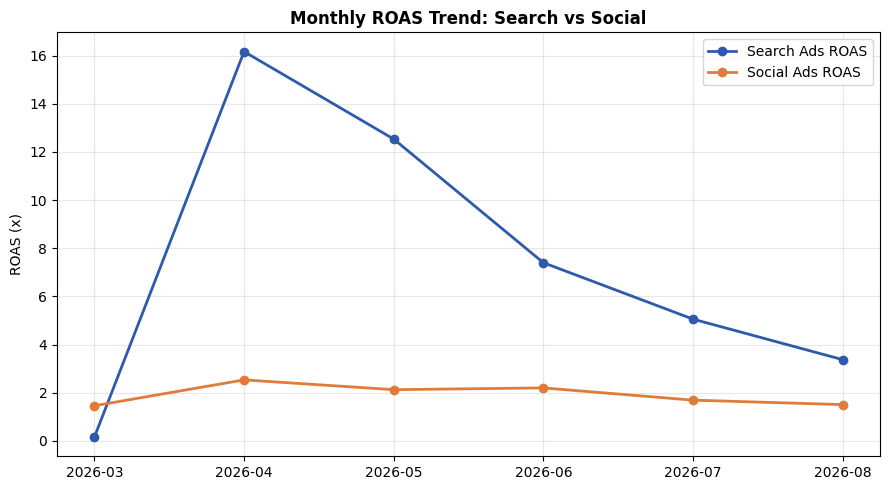

             Spend    Revenue   ROAS
Month                               
2026-03   66542.20   10476.87   0.16
2026-04   22998.66  371918.41  16.17
2026-05   35896.97  450063.43  12.54
2026-06   99646.33  737412.13   7.40
2026-07  106004.60  535935.26   5.06
2026-08   66526.00  224347.85   3.37

              Spend     Revenue  ROAS
Month                                
2026-03   449363.12   654344.70  1.46
2026-04   536859.92  1358759.90  2.53
2026-05   595063.44  1264161.22  2.12
2026-06  1618244.77  3556239.44  2.20
2026-07  1336918.87  2258477.07  1.69
2026-08  1346342.33  2024997.28  1.50


In [8]:
search_ads['Month'] = search_ads['Date'].dt.to_period('M').astype(str)
social_ads['Month'] = social_ads['Date'].dt.to_period('M').astype(str)

s_monthly = search_ads.groupby('Month').agg(Spend=('Cost (INR)','sum'), Revenue=('Conv. Value (INR)','sum'))
s_monthly['ROAS'] = s_monthly['Revenue'] / s_monthly['Spend']

soc_monthly = social_ads.groupby('Month').agg(Spend=('Amount Spent (INR)','sum'), Revenue=('Purchases Conversion Value (INR)','sum'))
soc_monthly['ROAS'] = soc_monthly['Revenue'] / soc_monthly['Spend']

fig, ax = plt.subplots()
ax.plot(s_monthly.index, s_monthly['ROAS'], marker='o', color=BRAND, linewidth=2, label='Search Ads ROAS')
ax.plot(soc_monthly.index, soc_monthly['ROAS'], marker='o', color=ORANGE, linewidth=2, label='Social Ads ROAS')
ax.set_title('Monthly ROAS Trend: Search vs Social', fontweight='bold')
ax.set_ylabel('ROAS (x)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(s_monthly.round(2))
print()
print(soc_monthly.round(2))

**Finding pattern:** if both platforms peak and decline on the same timeline, that's a signal to look for a shared cause (creative fatigue, audience saturation) rather than debugging each platform separately.

### 2.3 Funnel analysis — where are shoppers dropping off?

In [9]:
funnel = {
    'Impressions': social_ads['Impressions'].sum(),
    'Clicks (all)': social_ads['Clicks (all)'].sum(),
    'Landing Page Views': social_ads['Landing Page Views'].sum(),
    'Adds to Cart': social_ads['Adds to Cart'].sum(),
    'Checkouts Initiated': social_ads['Checkouts Initiated'].sum(),
    'Purchases': social_ads['Purchases'].sum(),
}
for stage, value in funnel.items():
    print(f"{stage:22s}: {value:,.0f}")

atc_to_checkout = funnel['Checkouts Initiated'] / funnel['Adds to Cart'] * 100
print(f"\nAdd-to-Cart -> Checkout-Initiated conversion: {atc_to_checkout:.2f}%")

Impressions           : 37,500,146
Clicks (all)          : 2,444,960
Landing Page Views    : 1,084,142
Adds to Cart          : 32,721
Checkouts Initiated   : 303
Purchases             : 836

Add-to-Cart -> Checkout-Initiated conversion: 0.93%


**Method note:** a useful sanity check when a funnel stage looks abnormally low is to compare it against the *next* stage down — if 'purchases' ends up higher than 'checkouts initiated', that's a strong signal of a tracking gap rather than (or in addition to) real user drop-off. Worth flagging as unproven rather than assuming either cause.

## Part 3 — Campaign / Ad Set / Ad Audit

Account-level numbers hide a lot. Thresholds used throughout: **ROAS ≥ 2.0x** (spend above a meaningful minimum) = winner · **1.0x–2.0x** = marginal · **< 1.0x** = loser.

All names below are the anonymized `(Anon)` labels created in Part 1.4.

### 3.1 Search Ads — campaign level

In [10]:
s_campaign = search_ads.groupby('Campaign (Anon)').agg(
    Spend=('Cost (INR)','sum'), Revenue=('Conv. Value (INR)','sum'), Status=('Campaign Status','last'))
s_campaign['ROAS'] = s_campaign['Revenue'] / s_campaign['Spend']
s_campaign = s_campaign.sort_values('ROAS', ascending=False)
print(s_campaign.round(2))

                    Spend    Revenue   Status   ROAS
Campaign (Anon)                                     
Campaign_4       71651.03  865423.78  ENABLED  12.08
Campaign_5       57979.47  543089.36  ENABLED   9.37
Campaign_8       90984.83  582689.54  ENABLED   6.40
Campaign_6       52519.84  213091.20  ENABLED   4.06
Campaign_9       48571.24  115275.42  ENABLED   2.37
Campaign_7       14211.36    8828.71   PAUSED   0.62
Campaign_2       35131.10    1755.93   PAUSED   0.05
Campaign_1       19286.30       0.00   PAUSED   0.00
Campaign_3        7279.60       0.00   PAUSED   0.00


### 3.2 Social Ads — campaign level

In [11]:
soc_campaign = social_ads.groupby('Campaign Name (Anon)').agg(
    Spend=('Amount Spent (INR)','sum'), Revenue=('Purchases Conversion Value (INR)','sum'),
    Status=('Campaign Effective Status','last'))
soc_campaign['ROAS'] = soc_campaign['Revenue'] / soc_campaign['Spend']
soc_campaign = soc_campaign.sort_values('Spend', ascending=False)
print(soc_campaign.round(2))

                           Spend     Revenue  Status   ROAS
Campaign Name (Anon)                                       
Campaign_4            1573535.76  3587712.77  ACTIVE   2.28
Campaign_9            1273792.53  2255391.20  ACTIVE   1.77
Campaign_11            513696.82  1009673.54  ACTIVE   1.97
Campaign_2             423392.29   469481.88  PAUSED   1.11
Campaign_10            419924.06   684171.98  PAUSED   1.63
Campaign_5             372301.21   606698.92  PAUSED   1.63
Campaign_6             369424.42   781694.18  ACTIVE   2.12
Campaign_8             296074.99   653010.98  PAUSED   2.21
Campaign_3             220786.72   394673.94  ACTIVE   1.79
Campaign_14            199729.25   429793.80  PAUSED   2.15
Campaign_1              58387.95   130460.12  PAUSED   2.23
Campaign_18             52557.67    42570.00  PAUSED   0.81
Campaign_12             27669.95    35660.10  PAUSED   1.29
Campaign_22             22153.45        0.00  PAUSED   0.00
Campaign_20             18734.67        

### 3.3 Social Ads — ad set level: find high-spend, low-return ad sets

In [12]:
soc_adset = social_ads.groupby(['Campaign Name (Anon)','Ad Set Name (Anon)']).agg(
    Spend=('Amount Spent (INR)','sum'), Revenue=('Purchases Conversion Value (INR)','sum'))
soc_adset['ROAS'] = soc_adset['Revenue'] / soc_adset['Spend']

meaningful_spend_threshold = soc_adset['Spend'].quantile(0.5)  # use median as an illustrative cutoff
losers = soc_adset[(soc_adset['Spend'] > meaningful_spend_threshold) & (soc_adset['ROAS'] < 1.0)].sort_values('Spend', ascending=False)
print(f"Ad sets above median spend with ROAS < 1.0x: {len(losers)}")
print(losers.head(10).round(2))

Ad sets above median spend with ROAS < 1.0x: 17
                                             Spend    Revenue  ROAS
Campaign Name (Anon) Ad Set Name (Anon)                            
Campaign_2           AdSet_7             152416.79  149679.78  0.98
Campaign_14          AdSet_38             66284.59   41180.00  0.62
Campaign_9           AdSet_30             64119.21   50280.00  0.78
Campaign_10          AdSet_38             57670.38   25228.42  0.44
Campaign_2           AdSet_23             52302.97       0.00  0.00
Campaign_10          AdSet_22             50614.78   25190.00  0.50
Campaign_11          AdSet_40             39870.22       0.00  0.00
Campaign_9           AdSet_33             29522.67   20869.00  0.71
Campaign_11          AdSet_34             21298.50       0.00  0.00
Campaign_14          AdSet_45             15785.19       0.00  0.00


### 3.4 Social Ads — ad/creative level: winners, losers, and fatigue detection

In [13]:
soc_ad = social_ads.groupby('Ad Name (Anon)').agg(
    Spend=('Amount Spent (INR)','sum'), Revenue=('Purchases Conversion Value (INR)','sum'))
soc_ad['ROAS'] = soc_ad['Revenue'] / soc_ad['Spend']

meaningful = soc_ad[soc_ad['Spend'] > soc_ad['Spend'].quantile(0.5)]
losing_ads = meaningful[meaningful['ROAS'] < 1.0]
print(f"Ads above median spend: {len(meaningful)}  |  of which ROAS < 1.0x: {len(losing_ads)}")
print(f"That's {len(losing_ads)/len(meaningful)*100:.0f}% of meaningfully-spent ads losing money.\n")

# Fatigue check: CTR and CPC trend for the top-spend ad
top_ad_name = soc_ad.sort_values('Spend', ascending=False).index[0]
sub = social_ads[social_ads['Ad Name (Anon)'] == top_ad_name]
ad_monthly = sub.groupby('Month').agg(Spend=('Amount Spent (INR)','sum'), Clicks=('Clicks (all)','sum'),
                                        Impressions=('Impressions','sum'))
ad_monthly['CTR%'] = ad_monthly['Clicks'] / ad_monthly['Impressions'] * 100
ad_monthly['CPC'] = ad_monthly['Spend'] / ad_monthly['Clicks']
print(f"Top-spend ad: {top_ad_name}")
print(ad_monthly[['CTR%','CPC']].round(2))

Ads above median spend: 89  |  of which ROAS < 1.0x: 28
That's 31% of meaningfully-spent ads losing money.



Top-spend ad: Ad_41
          CTR%   CPC
Month               
2026-05  11.73  3.28
2026-06  13.23  3.09
2026-07  11.31  0.96
2026-08   8.75  0.65


**Fatigue signature to watch for:** CTR falling while CPC rises *in the same period, on the same ad* — that combination is a much stronger signal than either metric alone, since either one can move for unrelated reasons.

## Part 4 — Budget Reallocation & the Growth Challenge

### 4.1 Recent run-rate — used as the reallocation baseline

Using a recent-window run-rate (e.g., trailing 3 months) rather than the full historical average keeps the reallocation baseline reflective of how the account is *actually* operating today.

In [14]:
recent_window_start = search_ads['Date'].max() - pd.Timedelta(days=90)
recent_s = search_ads[search_ads['Date'] >= recent_window_start]
recent_soc = social_ads[social_ads['Date'] >= recent_window_start]

recent_s_campaign = recent_s.groupby('Campaign (Anon)').agg(Spend=('Cost (INR)','sum'), Revenue=('Conv. Value (INR)','sum'))
recent_s_campaign['ROAS'] = recent_s_campaign['Revenue'] / recent_s_campaign['Spend']
recent_s_campaign['AvgMonthlySpend'] = recent_s_campaign['Spend'] / 3

recent_soc_campaign = recent_soc.groupby('Campaign Name (Anon)').agg(Spend=('Amount Spent (INR)','sum'), Revenue=('Purchases Conversion Value (INR)','sum'))
recent_soc_campaign['ROAS'] = recent_soc_campaign['Revenue'] / recent_soc_campaign['Spend']
recent_soc_campaign['AvgMonthlySpend'] = recent_soc_campaign['Spend'] / 3

print("Search Ads — recent-window ROAS by campaign:")
print(recent_s_campaign[['AvgMonthlySpend','ROAS']].sort_values('AvgMonthlySpend', ascending=False).round(2))
print("\nSocial Ads — recent-window ROAS by campaign (top 10):")
print(recent_soc_campaign[['AvgMonthlySpend','ROAS']].sort_values('AvgMonthlySpend', ascending=False).head(10).round(2))

Search Ads — recent-window ROAS by campaign:
                 AvgMonthlySpend   ROAS
Campaign (Anon)                        
Campaign_8              19888.04   3.63
Campaign_5              18841.17   9.42
Campaign_6              17506.61   4.06
Campaign_4              17089.39  10.01
Campaign_9              16190.41   2.37
Campaign_7               4566.63   0.64

Social Ads — recent-window ROAS by campaign (top 10):
                      AvgMonthlySpend  ROAS
Campaign Name (Anon)                       
Campaign_9                  424222.11  1.76
Campaign_4                  399790.75  2.14
Campaign_11                 170716.04  1.97
Campaign_10                 139511.15  1.63
Campaign_6                   67577.12  2.25
Campaign_14                  66576.42  2.15
Campaign_2                   55797.87  1.24
Campaign_3                   54935.27  1.89
Campaign_8                   36183.08  1.51
Campaign_1                   19462.65  2.23


### 4.2 The growth math

The core formula for "X% more sales at flat spend": Current Sales, Target Sales, Current Spend, Current ROAS, Required ROAS, Required Efficiency Gain.

In [15]:
GROWTH_TARGET_PCT = 0.25  # 25% — parameterized so this notebook works for any target

current_sales = sales['Total Sales (INR)'].sum()
current_spend = search_ads['Cost (INR)'].sum() + social_ads['Amount Spent (INR)'].sum()
target_sales = current_sales * (1 + GROWTH_TARGET_PCT)
target_spend = current_spend  # unchanged, by design
current_roas = current_sales / current_spend
required_roas = target_sales / target_spend
required_efficiency_gain = (required_roas / current_roas - 1) * 100

print(f"Current Sales:              {current_sales:,.0f}")
print(f"Target Sales (+{GROWTH_TARGET_PCT*100:.0f}%):        {target_sales:,.0f}")
print(f"Current Spend:              {current_spend:,.0f}")
print(f"Target Spend (unchanged):   {target_spend:,.0f}")
print(f"Current ROAS:               {current_roas:.2f}x")
print(f"Required ROAS:              {required_roas:.2f}x")
print(f"Required Efficiency Gain:   +{required_efficiency_gain:.1f}%")

Current Sales:              24,041,097
Target Sales (+25%):        30,051,371
Current Spend:              6,280,407
Target Spend (unchanged):   6,280,407
Current ROAS:               3.83x
Required ROAS:              4.78x
Required Efficiency Gain:   +25.0%


**Key insight (general, reusable):** whenever spend is held flat, the required efficiency gain is *always* mathematically equal to the sales growth target — this falls straight out of the ROAS = Sales ÷ Spend identity. Worth stating explicitly in any client-facing version of this analysis, since it reframes "can we hit X% growth?" into the more answerable "can we get X% more efficient?"

**On feasibility verdicts:** a growth target should be judged against the account's *own* evidence — trend direction, spend concentration in already-proven winners, and any known unresolved issues (like a funnel gap) — rather than assumed achievable by default. Stating a range (e.g., "reallocation alone likely closes 30-50% of the required gap") is more useful to a stakeholder than a binary yes/no.

## Appendix — Notes for Reusing This Notebook

This notebook is written to generalize beyond the original engagement:
- Column names follow common Google Ads / Meta Ads Manager / Shopify export conventions — swap in any similarly-structured export.
- The anonymization step (Part 1.4) can be toggled on/off depending on whether you're producing an internal report (real names) or a portfolio/external version (anonymized).
- `GROWTH_TARGET_PCT` in Part 4.2 is parameterized — change it to model any target growth percentage.
- Thresholds (ROAS cutoffs, spend minimums) are stated explicitly wherever used — treat them as configurable, not fixed constants, since the "right" threshold depends on the account's margin structure and typical spend levels.